In [2]:
import os
from pathlib import Path
from glob import glob
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision # Issues installing... resolved!
import cv2 # Not available from current channels.. resolved - conda-forge FTW

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

It looks like you set device to be `cuda` above, but that's an NVidia thing (I think --- at least it's definitely not a mac thing).  You need to use Metal.  I got it to work on my machine.  

In [3]:
# https://developer.apple.com/metal/pytorch/

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [4]:
device = torch.device('mps') if torch.backends.mps.is_available() else 'cpu'
SEED = 1984

In [5]:
device

device(type='mps')

In [6]:
# page 150 of Ayyadevara and Reddy
# Does glob too!
PATH = Path('.').absolute().parent
data_dir = PATH / 'data' / 'fruits-360_dataset_100x100'
train_data_dir = data_dir / 'Training'
test_data_dir  = data_dir / 'Test'

In [7]:
PATH

PosixPath('/Users/trobacker/ml_projects/Projects/ImageClassification')

In [8]:
print('Folders :', os.listdir(str(data_dir)))
classes =  os.listdir(str(train_data_dir))  # train_data_dir.iterdir()
print(f'{len(classes)} classes :', classes)

Folders : ['LICENSE', 'Test', 'Training', 'readme.md']
141 classes : ['Tomato 4', 'Corn Husk 1', 'Huckleberry 1', 'Tomato 3', 'Strawberry Wedge 1', 'Physalis 1', 'Pineapple 1', 'Avocado 1', 'Pear Kaiser 1', 'Grape Blue 1', 'Cactus fruit 1', 'Apple Granny Smith 1', 'Cherry 1', 'Tomato 2', 'Grapefruit Pink 1', 'Melon Piel de Sapo 1', 'Eggplant long 1', 'Grape White 1', 'Carrot 1', 'Redcurrant 1', 'Pear Stone 1', 'Maracuja 1', 'Nut Pecan 1', 'Quince 1', 'Nut Forest 1', 'Cocos 1', 'Grapefruit White 1', 'Raspberry 1', 'Apple Braeburn 1', 'Tamarillo 1', 'Banana Lady Finger 1', 'Hazelnut 1', 'Cabbage white 1', 'Mandarine 1', 'Kumquats 1', 'Apricot 1', 'Banana Red 1', 'Papaya 1', 'Mangostan 1', 'Apple Golden 2', 'Carambula 1', 'Peach Flat 1', 'Apple Red 1', 'Peach 1', 'Cherry Wax Yellow 1', 'Granadilla 1', 'Avocado ripe 1', 'Pomegranate 1', 'Mulberry 1', 'Mango 1', 'Apple Golden 3', 'Cucumber 3', 'Zucchini 1', 'Walnut 1', 'Tomato Heart 1', 'Cherry Rainier 1', 'Apple Red Yellow 1', 'Plum 1', 'N

In [9]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor

dataset = ImageFolder(str(data_dir) + '/Training', transform=ToTensor())
print('Size of training dataset :', len(dataset))
test = ImageFolder(str(data_dir) + '/Test', transform=ToTensor())
print('Size of test dataset :', len(test))

Size of training dataset : 70491
Size of test dataset : 23619


In [10]:
# view one image shape of the dataset.
img, label = dataset[599]
print(img.shape)

torch.Size([3, 100, 100])


Label:  Banana Red 1 (20)


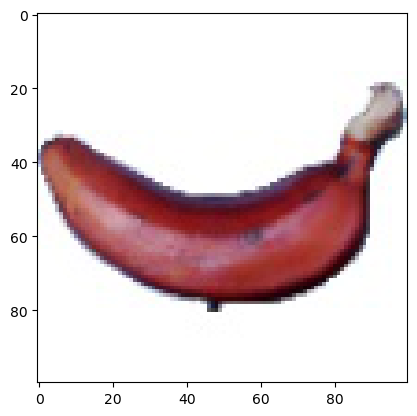

In [11]:
# function for the showing the image.
def show_image(img, label):
    print('Label: ', dataset.classes[label], "("+str(label)+")")
    plt.imshow(img.permute(1, 2, 0))
    
show_image(*dataset[10001])

Label:  Onion Red Peeled 1 (82)


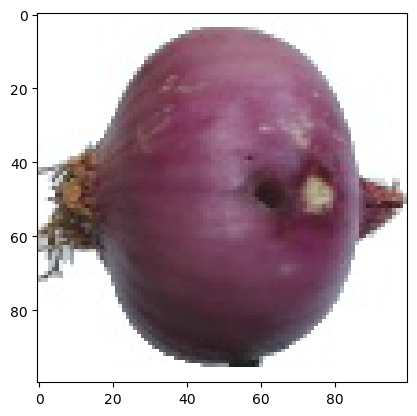

In [12]:
show_image(*dataset[40000])

In [13]:
from torchvision.utils import make_grid
from torch.utils.data import random_split

torch.manual_seed(20)
val_size = len(dataset)//10
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])
len(train_ds), len(val_ds) # train_ds length = dataset length - val_ds length

(63442, 7049)

Label:  Walnut 1 (137)


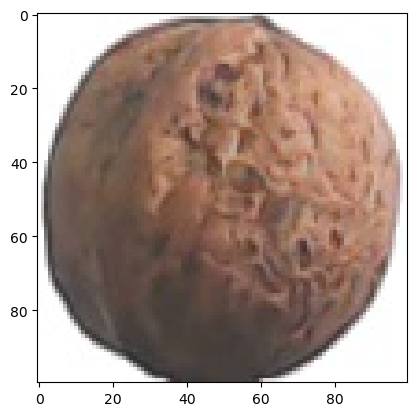

In [14]:
img, label = train_ds[1]
show_image(*train_ds[100]) # * and **!! LEARN MORE

In [15]:
batch_size = 64
train_loader = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size*2, num_workers=4, pin_memory=True)
test_loader = DataLoader(test, batch_size*2, num_workers=4, pin_memory=True)

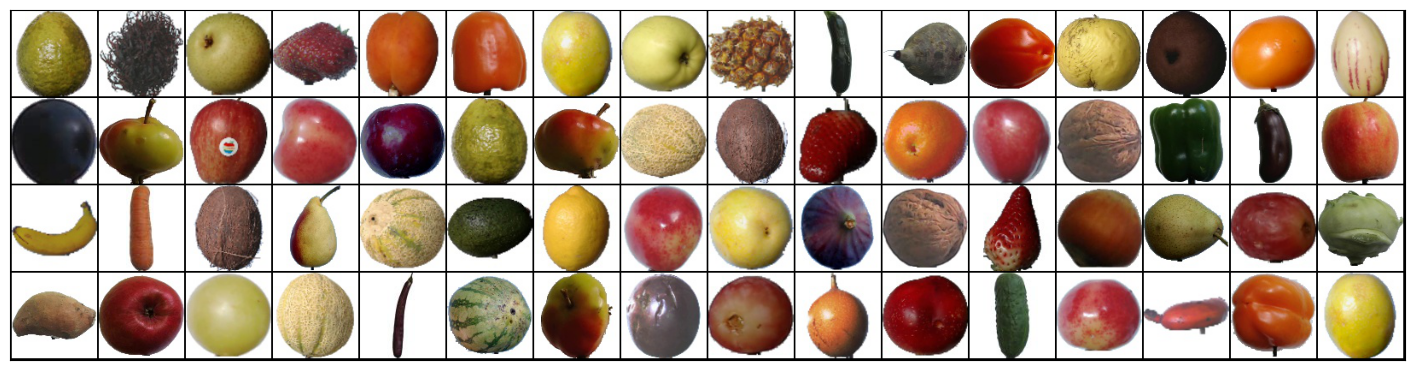

In [16]:
for images, labels in train_loader:
    fig, ax = plt.subplots(figsize=(18,10))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(images, nrow=16).permute(1, 2, 0))
    break

In [17]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data.dataloader import DataLoader

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))

In [ ]:
class CnnModel(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 98, kernel_size=3),
            nn.ReLU(), 
            nn.MaxPool2d(2,2),
            
        #     nn.Conv2d(98, 32, kernel_size=3),
        #     nn.ReLU(), 
        #     nn.MaxPool2d(2,2),

        #     nn.Conv2d(32, 47, kernel_size=3),
        #     nn.ReLU(), 
        #     nn.MaxPool2d(2,2),

        #     nn.Conv2d(128, 21, kernel_size=3),
        #     nn.ReLU(), 
        #     nn.MaxPool2d(2,2),

        #     nn.Flatten(),
        #     nn.Linear(4096, out_features=141)
        #     nn.Softmax(out_features=141)
        # )
            nn.Conv2d(3, 100, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(100, 150, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 150 x 16 x 16

            nn.Conv2d(150, 200, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(200, 200, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 200 x 8 x 8

            nn.Conv2d(200, 250, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(250, 250, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 250 x 4 x 4

            nn.Flatten(), 
            nn.Linear(36000, 1000),
            nn.ReLU(),
            nn.Linear(1000, 500),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(500, 141))
        
    def forward(self, xb):
        return self.network(xb)

In [41]:
model = CnnModel()
# model.cuda()

In [42]:
for images, labels in train_loader:
    print('images.shape:', images.shape)
    out = model(images)
    print('out.shape:', out.shape)
    #print('out[0]:', out[0])
    break

images.shape: torch.Size([64, 3, 100, 100])
out.shape: torch.Size([64, 141])


In [ ]:
# device = get_default_device()
device
model = model.to(device)

In [ ]:
device # MAC is mps "Metal ..."

device(type='mps')

In [ ]:
from tqdm.notebook import tqdm

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase 
        model.train()
        train_losses = []
        for batch in tqdm(train_loader):
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [26]:
torch.mps.device_count()

1

In [ ]:
fit(epochs=10, lr = 0.01, model = model, train_loader = train_loader, val_loader = val_loader)

  0%|          | 0/992 [00:00<?, ?it/s]

RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

In [ ]:
# train_dl = DeviceDataLoader(train_loader, device)
# val_dl = DeviceDataLoader(val_loader, device)
# to_device(model, device)

NameError: name 'to_device' is not defined

In [43]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase 
        model.train()
        train_losses = []
        for batch in tqdm(train_loader):
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [45]:
history=[evaluate(model, val_loader)]
history

IndexError: Target 132 is out of bounds.

In [32]:
class fruits_ds(Dataset):
    def __init__(self, folder, apple_type, orange_type):
        apples  = glob(str(folder) + f'/{apple_type}/*')
        oranges = glob(str(folder) + f'/{orange_type}/*')
        self.fpaths = apples + oranges

        # Randomize file paths and create target variables based on the folder corresponding to these file paths
        from random import shuffle, seed
        seed(SEED)
        shuffle(self.fpaths)
        self.targets = [fpath.split('/')[-1].startswith(orange_type) for fpath in self.fpaths] # Orange = 1
    
    def __len__(self): 
        return len(self.fpaths)

    def __getitem__(self, index):
        f = self.fpaths[index]
        target = self.targets[index]
        im = (cv2.imread(f)[:,:,::-1])
        #im = cv2.resize(im, (224,224))
        return torch.tensor(im/255).permute(2,0,1).float().to(device), \
               torch.tensor([target]).float().to(device)

Issue with this now is that 'apples' and 'oranges' are folders not the individual images! 

In [33]:
data = fruits_ds(train_data_dir, 'Apple Braeburn 1', 'Orange 1') #type(data)
data[1]
im, label = data[1]

tensor([0.], device='mps:0')


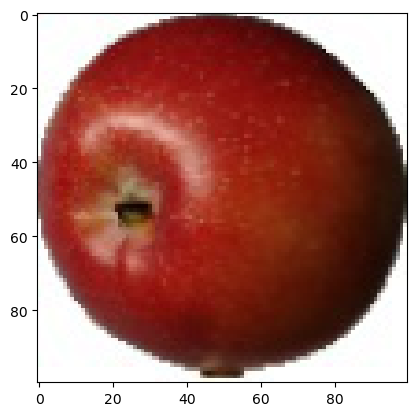

In [34]:
plt.imshow(im.permute(1,2,0).cpu())
print(label)